# Empirical-Bayes P1 enrichment
gene×event-type token 정의와 LR은 P1과 동일하다. token별 암종 발생률 추정만 global prior 기반 Beta-Binomial posterior log-odds로 교체하여 희귀 신호의 과도한 제거를 줄인다.

In [1]:
from pathlib import Path
import subprocess, sys
ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'experiments/gs/notebooks/exp_model_002/common/run_p1_axis.py').exists())
RUNNER=ROOT/'experiments/gs/notebooks/exp_model_002/common/run_p1_axis.py'; RESULT=RUNNER.parent.parent/'result'
RUN_ID='exp-empirical-bayes-enrichment-01'; SEED=42; RUN_EXPERIMENT=True
# 고정 prior: alpha=1, prior-strength=20, clip=4; test 통계/선택 없음

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 398.52it/s]


          variant  oof_macro_f1  feature_count  convergence_warning_count  leakage_check  nan_as_mutation_count  runtime_seconds
P1 multinomial LR      0.527550         8201.2                          0           True                      0        78.060740
               eb      0.534084         8201.2                          0           True                      0        78.068315


,variant,oof_macro_f1,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds
0,P1 multinomial LR,0.527550,8201.2,0,True,0,78.060740
1,eb,0.534084,8201.2,0,True,0,78.068315


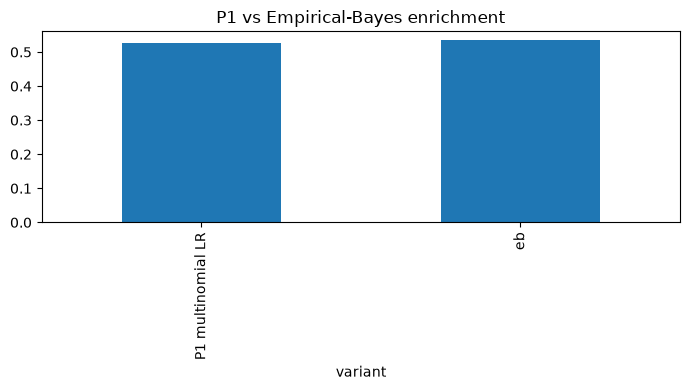

In [2]:
if RUN_EXPERIMENT: subprocess.run([sys.executable,str(RUNNER),'--axis','eb','--seed',str(SEED),'--run-id',RUN_ID],check=True)
import pandas as pd, matplotlib.pyplot as plt
s=pd.read_csv(RESULT/f'{RUN_ID}_seed{SEED}_summary.csv'); assert s.leakage_check.all() and s.nan_as_mutation_count.eq(0).all(); display(s)
s.set_index('variant').oof_macro_f1.plot.bar(figsize=(7,4),title='P1 vs Empirical-Bayes enrichment'); plt.tight_layout(); plt.show()